# ICEV Modeling: Ensemble Models

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, RFE, SequentialFeatureSelector
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

In [3]:
import functions_file_3
from functions_file_3 import *

In [4]:
df = pd.read_csv("ICEV_modeling_ready.csv")
df = df.drop(columns={'Unnamed: 0'})
df = df.dropna()

In [5]:
len(df)

12493093

In [6]:
df.columns

Index(['vehid', 'trip', 'timestamp', 'speed_kmh', 'temp_degc',
       'inferred_class', 'transmission', 'displacement', 'cylinders',
       'day_of_week', 'road_class', 'elapsed_min', 'encon'],
      dtype='str')

In [7]:
TARGET = 'encon'
TEMPORAL_COL = 'timestamp'
ID_COLS = ['vehid', 'trip']
NUMERIC_COLS = ["speed_kmh", "temp_degc", "displacement", "cylinders", "elapsed_min"]
CATEGORICAL_COLS = ["inferred_class", "transmission", "day_of_week", "road_class"]

FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS

# Linear Regression - StatModels
Use a sample of the training set for feature selection and coefficient interpretation

## Simple Linear Model

In [8]:
# Temporal Split
train, dev, test = temporal_split(df)

Total rows: 12,493,093
Train: 12,243,231, 98.0%
Dev: 124,931, 1.0%
Test: 124,931, 1.0%


In [9]:
# use statmodels on a small sample size only
train_sample = train.sample(n=500000, random_state=1)
X_train, X_dev, X_test, y_train, y_dev, y_test, scaler = preprocess_for_ols(train_sample, dev, test)
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  encon   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     6701.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        15:04:58   Log-Likelihood:            -5.5780e+05
No. Observations:              500000   AIC:                         1.116e+06
Df Residuals:                  499982   BIC:                         1.116e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [10]:
X_dev_sm = sm.add_constant(X_dev, has_constant='add')
dev_pred = ols_model.predict(X_dev_sm)

In [27]:
evaluate("Simple Linear Regression on Dev", y_dev, dev_pred)

Simple Linear Regression on Dev
MAE: 0.4697 L/hr
RMSE: 0.6936 L/hr
R-squared: 0.2225
MAPE: 78.96%


In [29]:
X_train_sm = sm.add_constant(X_train, has_constant='add')
train_pred = ols_model.predict(X_train_sm)
evaluate("Simple Linear Regression on Train", y_train, train_pred)

Simple Linear Regression on Train
MAE: 0.5316 L/hr
RMSE: 0.7384 L/hr
R-squared: 0.1856
MAPE: 95.89%


## Linear with Stepwise Selection

In [30]:
train_stepwise = train.sample(n=500000,random_state=2)
X_sw, _, _, y_sw, _, _, _ = preprocess_for_ols(train_stepwise, dev.iloc[:1], test.iloc[:1])
selected_features = stepwise_selection(X_sw, y_sw, threshold_in=0.01, threshold_out=0.05)

print("Selected Features:")
print(selected_features)

Add inferred_class_Small           p=0.000000
Add displacement                   p=0.000000
Add speed_kmh                      p=0.000000
Add elapsed_min                    p=0.000000
Add temp_degc                      p=0.000000
Add road_class_Main                p=0.000000
Add inferred_class_Large           p=0.000000
Add cylinders                      p=0.000000
Add road_class_Residential         p=0.000000
Add road_class_Unclassified        p=0.000000
Add day_of_week_1                  p=0.000230
Add day_of_week_5                  p=0.001585
Selected Features:
['inferred_class_Small', 'displacement', 'speed_kmh', 'elapsed_min', 'temp_degc', 'road_class_Main', 'inferred_class_Large', 'cylinders', 'road_class_Residential', 'road_class_Unclassified', 'day_of_week_1', 'day_of_week_5']


In [31]:
# Re-train using only selected features
X_train_sel = X_train[selected_features]
X_dev_sel = X_dev[selected_features]
X_test_sel = X_test[selected_features]

# Add intercept
X_train_sel = sm.add_constant(X_train_sel)
X_dev_sel = sm.add_constant(X_dev_sel)
X_test_sel = sm.add_constant(X_test_sel)

# Train
final_model = sm.OLS(y_train, X_train_sel).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  encon   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     9492.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        15:15:26   Log-Likelihood:            -5.5781e+05
No. Observations:              500000   AIC:                         1.116e+06
Df Residuals:                  499987   BIC:                         1.116e+06
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [32]:
X_dev_sel = sm.add_constant(X_dev[selected_features], has_constant='add')
dev_pred = final_model.predict(X_dev_sel)
evaluate("Regression with Selection", y_dev, dev_pred)

Regression with Selection
MAE: 0.4696 L/hr
RMSE: 0.6935 L/hr
R-squared: 0.2228
MAPE: 78.95%


In [33]:
train_pred = final_model.predict(X_train_sel)
evaluate("Regression with Selection", y_train, train_pred)

Regression with Selection
MAE: 0.5316 L/hr
RMSE: 0.7384 L/hr
R-squared: 0.1855
MAPE: 95.87%


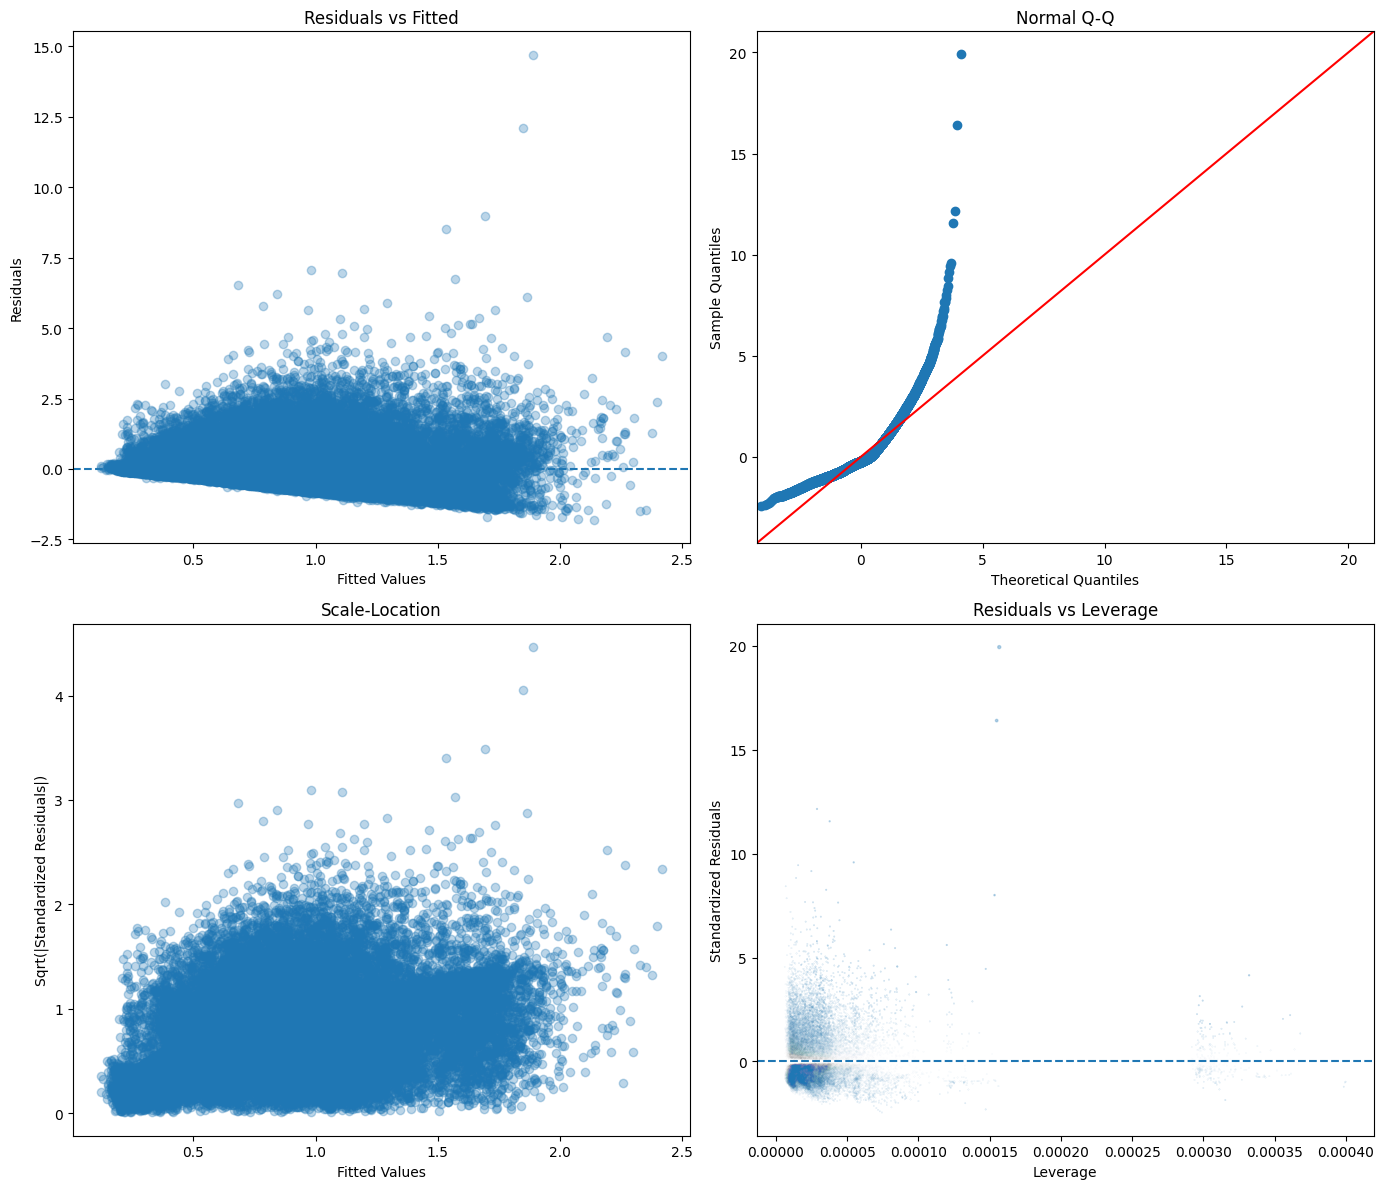

In [36]:
plot_regression_diagnostics(final_model)

## Linear with LassoCV (Scikit-Learn)

In [37]:
train_lasso = train.sample(n=1000000, random_state=42)
#X_train, X_dev, X_test, y_train, y_dev, y_test, scaler = preprocess_for_ols(train, dev, test)

In [38]:
lasso = LassoCV(cv=5, random_state=42, n_jobs=-1, max_iter=5000)
lasso.fit(X_train, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,5000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,-1


In [39]:
print("Best alpha:", lasso.alpha_)

Best alpha: 0.00031517495242655525


In [40]:
coef_df = pd.DataFrame({"feature": X_train.columns,
                        "coefficient": lasso.coef_})
selected_features = coef_df[coef_df["coefficient"] != 0].copy()
selected_features = selected_features.sort_values(by="coefficient", key=np.abs, ascending=False)

print(selected_features)

                    feature  coefficient
0                 speed_kmh     0.311496
2              displacement     0.105889
3                 cylinders     0.069860
14          road_class_Main    -0.061297
6     inferred_class_Medium     0.046564
5      inferred_class_Large    -0.042459
15   road_class_Residential    -0.039921
16  road_class_Unclassified    -0.033499
4               elapsed_min    -0.021400
1                 temp_degc    -0.019246
7      inferred_class_Small    -0.006578
12            day_of_week_5     0.005725
11            day_of_week_4    -0.004526
13            day_of_week_6     0.001094
9             day_of_week_2    -0.000413
10            day_of_week_3    -0.000005


In [41]:
selected_feature_names = selected_features["feature"].tolist()
print("Selected Features by LassoCV:")
print(selected_feature_names)

Selected Features by LassoCV:
['speed_kmh', 'displacement', 'cylinders', 'road_class_Main', 'inferred_class_Medium', 'inferred_class_Large', 'road_class_Residential', 'road_class_Unclassified', 'elapsed_min', 'temp_degc', 'inferred_class_Small', 'day_of_week_5', 'day_of_week_4', 'day_of_week_6', 'day_of_week_2', 'day_of_week_3']


In [42]:
len(selected_feature_names)

16

In [43]:
# Keep selected features
X_train_sel = X_train[selected_feature_names]
X_dev_sel   = X_dev[selected_feature_names]
X_test_sel  = X_test[selected_feature_names]
# Add intercept
X_train_sel = sm.add_constant(X_train_sel)
X_dev_sel   = sm.add_constant(X_dev_sel)
X_test_sel  = sm.add_constant(X_test_sel)
# Fit OLS
final_model = sm.OLS(y_train, X_train_sel).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  encon   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     7120.
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        15:22:14   Log-Likelihood:            -5.5780e+05
No. Observations:              500000   AIC:                         1.116e+06
Df Residuals:                  499983   BIC:                         1.116e+06
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [45]:
train_pred = final_model.predict(X_train_sel)
evaluate("Linear with LassoCV on Train set", y_train, train_pred)

Linear with LassoCV on Train set
MAE: 0.5316 L/hr
RMSE: 0.7384 L/hr
R-squared: 0.1856
MAPE: 95.88%


In [46]:
dev_pred = final_model.predict(X_dev_sel)
evaluate("Linear with LassoCV on Dev set", y_dev, dev_pred)

Linear with LassoCV on Dev set
MAE: 0.4697 L/hr
RMSE: 0.6936 L/hr
R-squared: 0.2226
MAPE: 78.95%


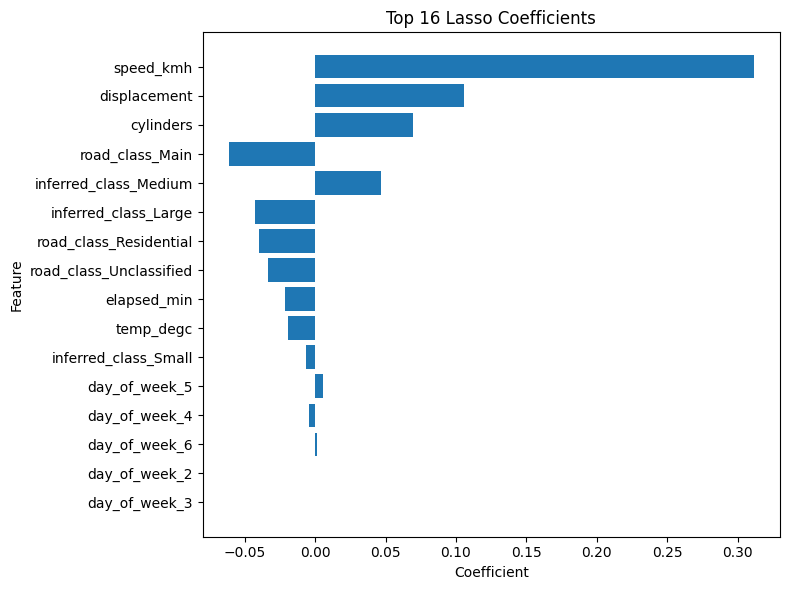

In [48]:
top_n = len(selected_features)
plot_df = selected_features.head(top_n)
plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"][::-1], plot_df["coefficient"][::-1])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Lasso Coefficients")
plt.tight_layout()
plt.show()

## Linear Regression Scikit Learn (no Sampling)

In [ ]:
# train, dev, test = temporal_split(df)

In [49]:
(X_train, X_dev, X_test, X_train_s, X_dev_s, X_test_s, 
y_train, y_dev, y_test, 
 scaler, encoders) = preprocess(train, dev, test)

Feature matrix shapes: (train: (12243231, 9), dev: (124931, 9), test: (124931, 9))
Target range for train set: [0.000, 83.600], mean=0.870


In [51]:
model = LinearRegression(n_jobs=-1)
model.fit(X_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [52]:
preds = model.predict(X_train_s)
evaluate("Linear Regression Scikit-learn on Train set", y_train, preds)

Linear Regression Scikit-learn on Train set
MAE: 0.5324 L/hr
RMSE: 0.7451 L/hr
R-squared: 0.1826
MAPE: 95.88%


In [53]:
preds = model.predict(X_dev_s)
evaluate("Linear Regression Scikit-learn on Dev set", y_dev, preds)

Linear Regression Scikit-learn on Dev set
MAE: 0.4697 L/hr
RMSE: 0.6924 L/hr
R-squared: 0.2254
MAPE: 79.45%


# Random Forest

## Random Forest: Baseline

In [54]:
# train, dev, test = temporal_split(df)

In [11]:
(X_train, X_dev, X_test, X_train_s, X_dev_s, X_test_s, 
 y_train, y_dev, y_test, 
 scaler, encoders) = preprocess(train, dev, test)

Preprocessing
Feature matrix shapes: (train: (12243231, 9), dev: (124931, 9), test: (124931, 9))
Target range (train): [0.000, 83.600], mean=0.870


In [56]:
subsample_frac = 0.3 # Subsampled to 30% of training data for tractable runtime at 13M rows.
n_estimators = 200

n_sub = int(len(X_train) * subsample_frac)
idx = np.random.choice(len(X_train), n_sub, replace=False)
X_sub, y_sub = X_train[idx], y_train[idx]
print(f"Subsampled to {n_sub:,} rows")

model = RandomForestRegressor(n_estimators=n_estimators,
                              max_depth=20,
                              min_samples_leaf=10,
                              max_features=0.5,
                              n_jobs=-1,
                              random_state=42,)
model.fit(X_sub, y_sub)

Subsampled to 3,672,969 rows


,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
train_pred = model.predict(X_train)
evaluate("Random Forest Baseline on Train Set", y_train, train_pred)

Random Forest Baseline on Train Set
MAE: 0.4881 L/hr
RMSE: 0.6878 L/hr
R-squared: 0.3036
MAPE: 88.28%


In [58]:
preds = model.predict(X_dev)
result = evaluate("Random Forest Baseline on Dev Set", y_dev, preds)

Random Forest Baseline on Dev Set
Random Forest Baseline on Dev Set
MAE: 0.4729 L/hr
RMSE: 0.6784 L/hr
R-squared: 0.2563
MAPE: 90.59%


## Random Forest: additional features
As multicollinearity would not be an issue for Random Forest, we'll try:
- acceleration
- rolling speed

### Fit Model 

In [59]:
df["delta_time_sec"] = df.groupby(["vehid", "trip"])["timestamp"].diff().fillna(0).div(1000)
df["accel"] = df.groupby(["vehid", "trip"])["speed_kmh"].diff()/ df["delta_time_sec"].fillna(0)

# Rolling speed (indicates if there's congestion, aggressive driving, transient engine load)
df["speed_roll_mean_10"] = df.groupby(["vehid", "trip"])["speed_kmh"].rolling(10).mean().reset_index(level=[0,1], drop=True)
df["accel_roll_std_10"] = df.groupby(["vehid", "trip"])["accel"].rolling(10).std().reset_index(level=[0,1], drop=True)

# Encode cyclical time
df["day_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["day_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

TARGET = 'encon'

RF_NUMERIC_COLS = ["speed_kmh", "temp_degc", "displacement", "cylinders", "elapsed_min", "accel", "speed_roll_mean_10", "accel_roll_std_10", "day_sin", "day_cos"]
RF_CATEGORICAL_COLS = ["inferred_class", "transmission", "road_class"]

RF_FEATURE_COLS = RF_NUMERIC_COLS + RF_CATEGORICAL_COLS

In [60]:
train, dev, test = temporal_split(df)

Total rows: 12,493,093
Train: 12,243,231, 98.0%
Dev: 124,931, 1.0%
Test: 124,931, 1.0%


In [61]:
encoders = {}

# Label-encode each categorical column
for col in RF_CATEGORICAL_COLS:
    le = LabelEncoder()
    le.fit(train[col].astype(str))
    encoders[col] = le
    train[col] = le.transform(train[col].astype(str))
    dev[col] = safe_transform(dev[col],  le)
    test[col] = safe_transform(test[col], le)

X_train = train[RF_FEATURE_COLS].values
X_dev = dev[RF_FEATURE_COLS].values
X_test = test[RF_FEATURE_COLS].values

y_train = train[TARGET].values
y_dev = dev[TARGET].values
y_test = test[TARGET].values

# StandardScaler (fit on train only)
num_idx = [RF_FEATURE_COLS.index(c) for c in RF_NUMERIC_COLS]
scaler = StandardScaler()
X_train_scaled = X_train.astype(float)
X_dev_scaled = X_dev.astype(float)
X_test_scaled = X_test.astype(float)
X_train_scaled[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
X_dev_scaled[:, num_idx] = scaler.transform(X_dev[:, num_idx])
X_test_scaled[:, num_idx] = scaler.transform(X_test[:, num_idx])

print(f"Feature matrix shapes (train): {X_train.shape}, dev: {X_dev.shape}, test: {X_test.shape}")
print(f"Target range (train): [{y_train.min():.3f}, {y_train.max():.3f}], mean={y_train.mean():.3f}")

Feature matrix shapes (train): (12243231, 13), dev: (124931, 13), test: (124931, 13)
Target range (train): [0.000, 83.600], mean=0.870


In [62]:
subsample_frac = 0.3 # Subsampled to 30% of training data for tractable runtime at 13M rows.
n_estimators=200

n_sub = int(len(X_train) * subsample_frac)
idx = np.random.choice(len(X_train), n_sub, replace=False)
X_sub, y_sub = X_train[idx], y_train[idx]
print(f"Subsampled to {n_sub:,} rows")

model = RandomForestRegressor(n_estimators=n_estimators,
                              max_depth=20,
                              min_samples_leaf=10,
                              max_features=0.5,
                              n_jobs=-1,
                              random_state=42,)
model.fit(X_sub, y_sub)

Subsampled to 3,672,969 rows


,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
train_pred = model.predict(X_train)
evaluate("Random Forest with additional features on Train set", y_train, train_pred)

Random Forest with additional features on Train set
MAE: 0.3609 L/hr
RMSE: 0.5452 L/hr
R-squared: 0.5623
MAPE: 59.83%


In [64]:
preds = model.predict(X_dev)
evaluate("Random Forest with additional features on Dev set", y_dev, preds)

Random Forest with additional features on Dev set
MAE: 0.3391 L/hr
RMSE: 0.5144 L/hr
R-squared: 0.5725
MAPE: 60.12%


In [65]:
importance_df = pd.DataFrame({"feature": RF_FEATURE_COLS, "importance": model.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df.head(20))

               feature  importance
0            speed_kmh    0.333565
5                accel    0.232707
6   speed_roll_mean_10    0.190205
7    accel_roll_std_10    0.086856
2         displacement    0.052651
4          elapsed_min    0.028017
3            cylinders    0.027577
1            temp_degc    0.018674
10      inferred_class    0.013188
8              day_sin    0.006474
12          road_class    0.005827
9              day_cos    0.004259
11        transmission    0.000000


### Diagnostics

In [66]:
FEATURE_NAMES = RF_FEATURE_COLS

Residual diagnostics


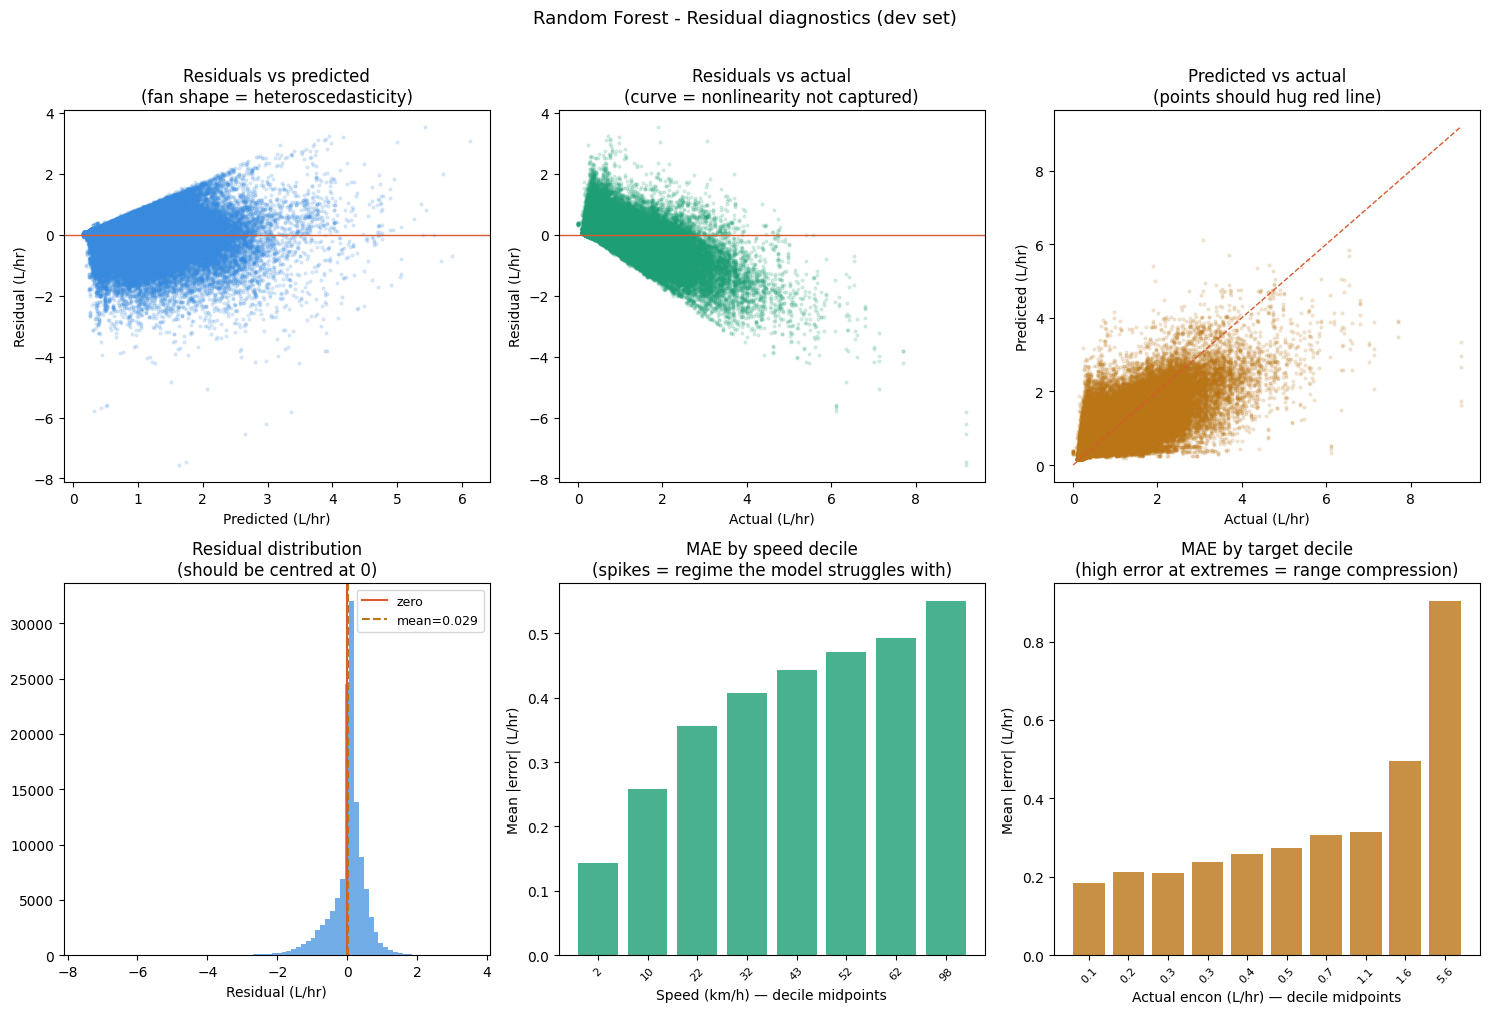

Residual mean : 0.0288, (bias; should be ~0)
Residual std : 0.5136
  Max overpredict : 3.5293
  Max underpredict: -7.5576
% within 1 L/hr : 93.7%


In [71]:
rf_plot(preds, y_dev, X_dev, "L/hr")

In [72]:
from sklearn.inspection import permutation_importance
# mean decrease in impurity
mdi = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values()
# Permutation importance on dev set
print("Computing permutation importance on dev set")
perm = permutation_importance(model, X_dev, y_dev, n_repeats=10, random_state=42, n_jobs=-1, scoring="r2")
perm_mean = pd.Series(perm.importances_mean, index=FEATURE_NAMES).sort_values()
perm_std = pd.Series(perm.importances_std, index=FEATURE_NAMES)

Computing permutation importance on dev set


In [73]:
C_BLUE   = "#378ADD"
C_CORAL  = "#D85A30"
C_TEAL   = "#1D9E75"
C_AMBER  = "#BA7517"
C_GRAY   = "#888780"
 

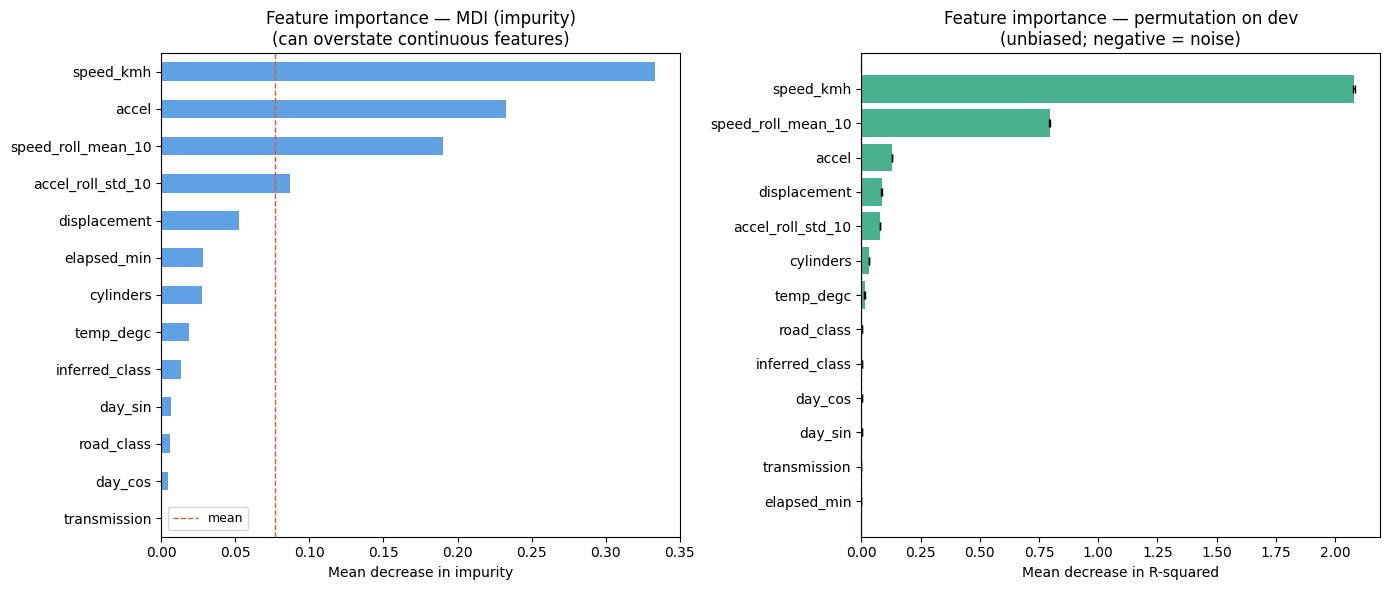

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# MDI bar
mdi.plot.barh(ax=axes[0], color=C_BLUE, alpha=0.8)
axes[0].set_title("Feature importance — MDI (impurity)\n(can overstate continuous features)")
axes[0].set_xlabel("Mean decrease in impurity")
axes[0].axvline(mdi.mean(), color=C_CORAL, linestyle="--", linewidth=1, label="mean")
axes[0].legend(fontsize=9)
 
# Permutation bar with error bars
axes[1].barh(perm_mean.index, perm_mean.values,
             xerr=perm_std[perm_mean.index].values,
             color=C_TEAL, alpha=0.8, capsize=3)
axes[1].set_title("Feature importance — permutation on dev\n(unbiased; negative = noise)")
axes[1].set_xlabel("Mean decrease in R-squared")
axes[1].axvline(0, color=C_CORAL, linestyle="--", linewidth=1)
 
plt.tight_layout()
plt.show()

## Random Forest: Tuning

### Randomized Search + Fit

In [75]:
from sklearn.model_selection import RandomizedSearchCV

In [76]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]}

In [77]:
idx = np.random.choice(len(X_train),200000, replace=False)
X_tune = X_train[idx]
y_tune = y_train[idx]

In [78]:
rf = RandomForestRegressor(n_jobs=-1, random_state=42)

search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=8,
                            cv=2,
                            verbose=2,
                            random_state=42,
                            scoring="neg_root_mean_squared_error")

search.fit(X_tune, y_tune)

Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=10, min_samples_split=5, n_estimators=300; total time=   4.1s
[CV] END max_depth=20, max_features=0.3, min_samples_leaf=10, min_samples_split=5, n_estimators=300; total time=   3.6s
[CV] END max_depth=10, max_features=0.5, min_samples_leaf=3, min_samples_split=10, n_estimators=300; total time=   4.5s
[CV] END max_depth=10, max_features=0.5, min_samples_leaf=3, min_samples_split=10, n_estimators=300; total time=   4.5s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   5.0s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=1, min_samples_split=10, n_estimators=300; total time=   5.1s
[CV] END max_depth=None, max_features=0.3, min_samples_leaf=3, min_samples_split=5, n_estimators=300; total time=   5.4s
[CV] END max_depth=None, max_features=0.3, min_samples_leaf=3, min_samples_split=5, n_estimators=30

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 0.3, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,8
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [79]:
search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 3,
 'max_features': 0.5,
 'max_depth': 30}

In [80]:
subsample_frac = 0.3 # Subsampled to 30% of training data for tractable runtime at 13M rows.

n_sub = int(len(X_train) * subsample_frac)
idx = np.random.choice(len(X_train), n_sub, replace=False)
X_sub, y_sub = X_train[idx], y_train[idx]
print(f"Subsampled to {n_sub:,} rows")

model = RandomForestRegressor(
    n_estimators= 300,
    min_samples_split=5,
    max_depth= 30,
    min_samples_leaf=3,
    max_features=0.5,
    n_jobs=-1,
    random_state=42)
model.fit(X_sub, y_sub)

Subsampled to 3,672,969 rows


,n_estimators,300
,criterion,'squared_error'
,max_depth,30
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
train_pred = model.predict(X_train)
evaluate("Random Forest Tuning on Train Set", y_train, train_pred)

Random Forest Tuning on Train Set
MAE: 0.3118 L/hr
RMSE: 0.4859 L/hr
R-squared: 0.6523
MAPE: 50.93%


In [82]:
preds = model.predict(X_dev)
evaluate("Random Forest Tuning on Dev Set", y_dev, preds)

Random Forest Tuning on Dev Set
MAE: 0.3504 L/hr
RMSE: 0.5178 L/hr
R-squared: 0.5668
MAPE: 65.94%


In [83]:
importance_df = pd.DataFrame({"feature": RF_FEATURE_COLS, "importance": model.feature_importances_})
importance_df = importance_df.sort_values("importance", ascending=False)
print(importance_df.head(20))

               feature  importance
0            speed_kmh    0.273062
6   speed_roll_mean_10    0.187460
5                accel    0.173532
7    accel_roll_std_10    0.111348
4          elapsed_min    0.077003
2         displacement    0.049298
1            temp_degc    0.048079
8              day_sin    0.022236
3            cylinders    0.022026
9              day_cos    0.014552
12          road_class    0.011742
10      inferred_class    0.009662
11        transmission    0.000000


### Diagnostics

Residual diagnostics


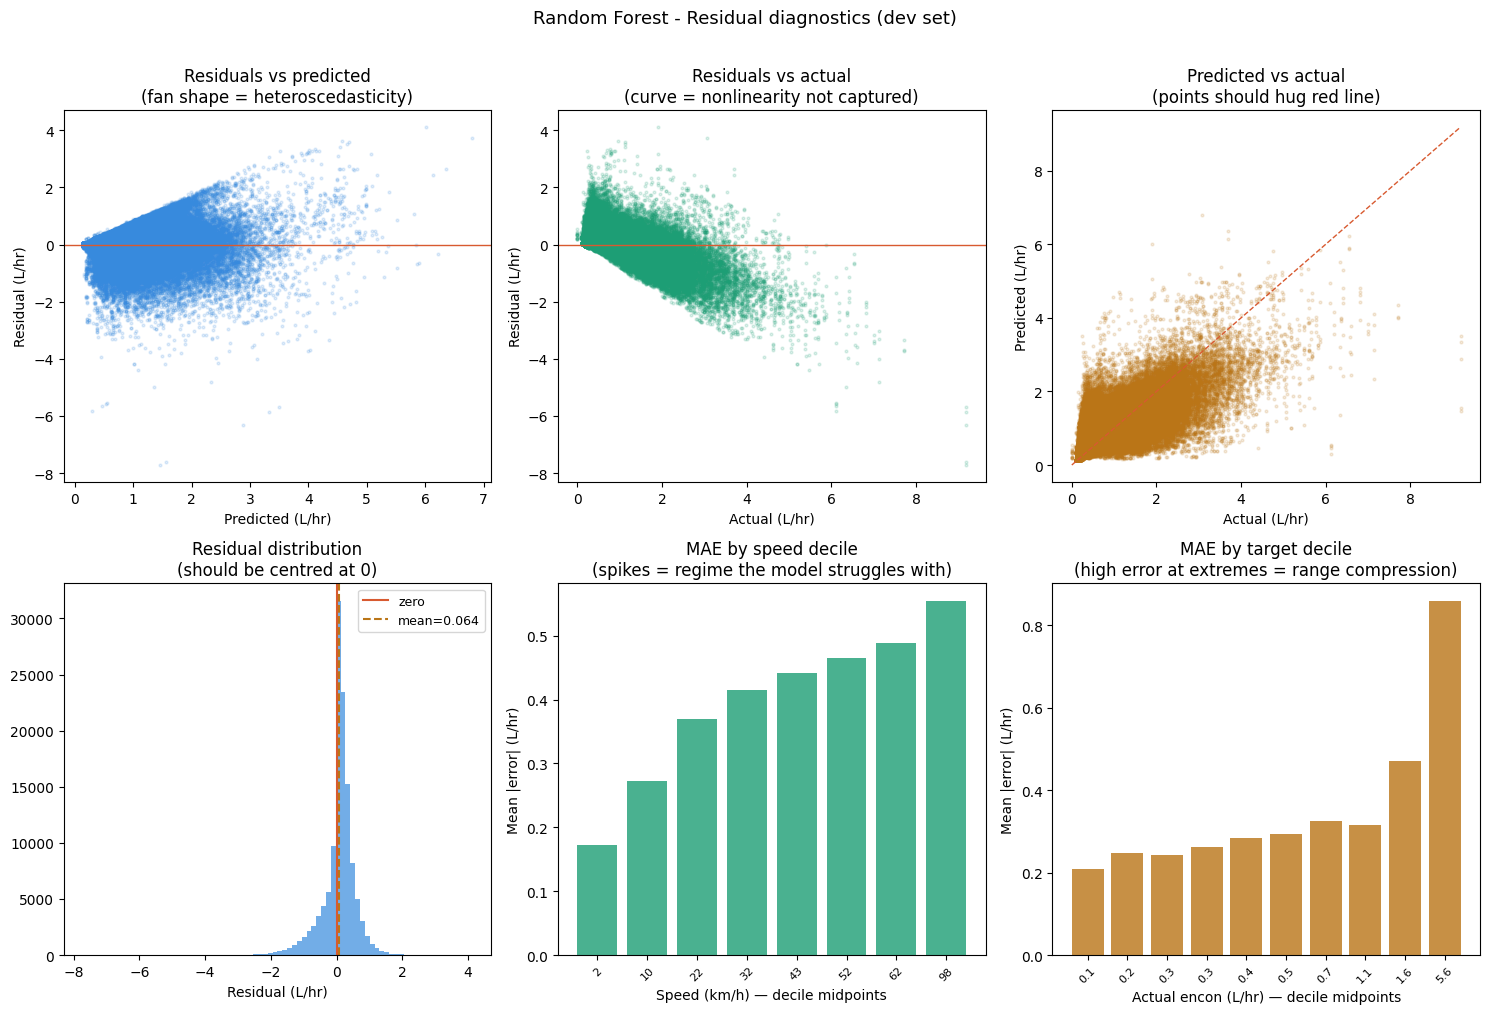

Residual mean : 0.0641, (bias; should be ~0)
Residual std : 0.5138
  Max overpredict : 4.1154
  Max underpredict: -7.7180
% within 1 L/hr : 93.7%


In [84]:
rf_plot(preds, y_dev, X_dev, "L/hr")

Tree depth mean: 30.0 min: 30, max: 30
Leaf nodes mean: 469944.44666666666  min: 420466, max: 506897
(!) Most trees hit max_depth= => they want to grow deeper.
=> Either raise max_depth or accept the current regularisation.


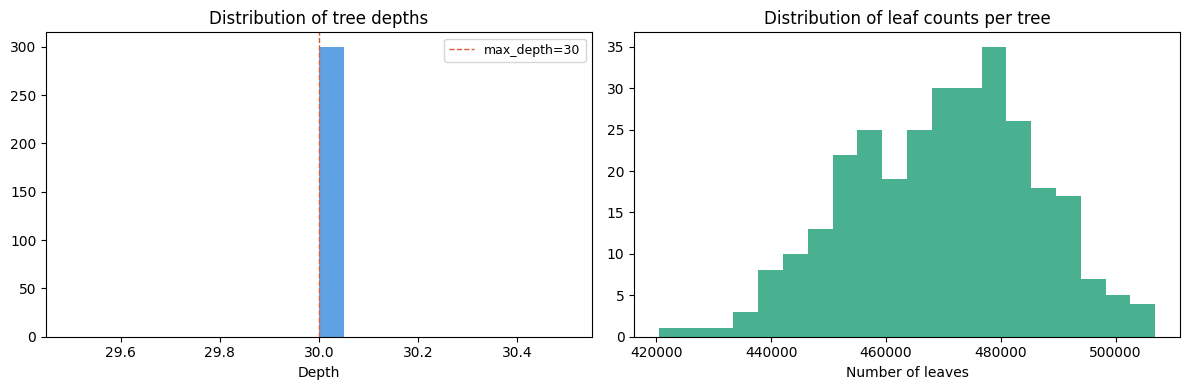

In [87]:
rf_tree_diagnostic(model, 30, 10)

 frac=10%  n=1,224,323  MAE=0.3541  R²=0.5559
 frac=20%  n=2,448,646  MAE=0.3529  R²=0.5634
 frac=30%  n=3,672,969  MAE=0.3567  R²=0.5602
 frac=50%  n=6,121,615  MAE=0.3549  R²=0.5629


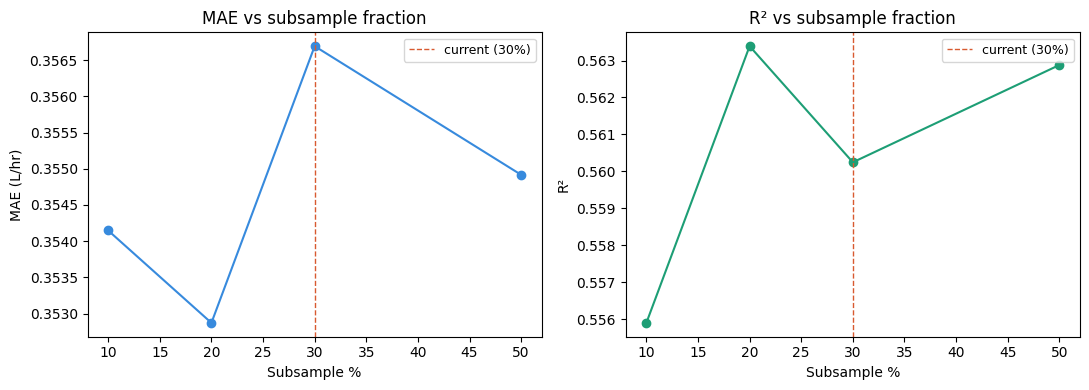

MAE has plateaued: 30% subsample is sufficient.


In [88]:
fracs = [0.10, 0.20, 0.30, 0.50]
results = []
for frac in fracs:
    n  = int(len(X_train) * frac)
    ix = np.random.choice(len(X_train), n, replace=False)
    m  = RandomForestRegressor(
            n_estimators=100,
            max_depth=30, min_samples_leaf=3,
            max_features=0.5, n_jobs=-1, random_state=42)
    m.fit(X_train[ix], y_train[ix])
    p   = m.predict(X_dev)
    mae = mean_absolute_error(y_dev, p)
    r2  = r2_score(y_dev, p)
    results.append(dict(frac=frac, n=n, MAE=mae, R2=r2))
    print(f" frac={frac:.0%}  n={n:>8,}  MAE={mae:.4f}  R²={r2:.4f}")
 
results_df = pd.DataFrame(results)
fig, axes  = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(results_df["frac"]*100, results_df["MAE"],
             marker="o", color=C_BLUE)
axes[0].axvline(30, color=C_CORAL, linestyle="--", linewidth=1, label="current (30%)")
axes[0].set_xlabel("Subsample %"); axes[0].set_ylabel("MAE (L/hr)")
axes[0].set_title("MAE vs subsample fraction"); axes[0].legend(fontsize=9)
 
axes[1].plot(results_df["frac"]*100, results_df["R2"],
             marker="o", color=C_TEAL)
axes[1].axvline(30, color=C_CORAL, linestyle="--", linewidth=1, label="current (30%)")
axes[1].set_xlabel("Subsample %"); axes[1].set_ylabel("R²")
axes[1].set_title("R-squared vs subsample fraction"); axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("rf_subsample_sensitivity.png", dpi=150)
plt.show()
 
plateau = results_df["MAE"].diff().abs().iloc[-1] < 0.005
if plateau:
    print("MAE has plateaued: 30% subsample is sufficient.")
else:
    print("MAE still improving at 50%: consider training on more data.")

# Gradient Boosting

In [8]:
# Already run this cell in Random Forest
df["delta_time_sec"] = df.groupby(["vehid", "trip"])["timestamp"].diff().fillna(0).div(1000)
df["accel"] = df.groupby(["vehid", "trip"])["speed_kmh"].diff()/ df["delta_time_sec"].fillna(0)

# Rolling speed (indicates if there's congestion, aggressive driving, transient engine load)
df["speed_roll_mean_10"] = df.groupby(["vehid", "trip"])["speed_kmh"].rolling(10).mean().reset_index(level=[0,1], drop=True)
df["accel_roll_std_10"] = df.groupby(["vehid", "trip"])["accel"].rolling(10).std().reset_index(level=[0,1], drop=True)

# Encode cyclical time
df["day_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["day_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

TARGET = 'encon'
RF_NUMERIC_COLS = ["speed_kmh", "temp_degc", "displacement", "cylinders", "elapsed_min", "accel", "speed_roll_mean_10", "accel_roll_std_10", "day_sin", "day_cos"]

RF_CATEGORICAL_COLS = ["inferred_class", "transmission", "road_class"]

RF_FEATURE_COLS = RF_NUMERIC_COLS + RF_CATEGORICAL_COLS

In [9]:
# Forward-fill within trip for null speed_roll_mean_10 and accel_roll_std_10
df = df.sort_values(["vehid", "trip", "timestamp"])
df["speed_roll_mean_10"] = (df.groupby(["vehid", "trip"])["speed_kmh"].rolling(10, min_periods=1).mean().reset_index(level=[0,1], drop=True))
df["accel_roll_std_10"] = (df.groupby(["vehid", "trip"])["accel"].rolling(10, min_periods=1).std().reset_index(level=[0,1], drop=True))
# Fill the rest of NaN with instant values
df["speed_roll_mean_10"] = df["speed_roll_mean_10"].fillna(df["speed_kmh"])
df["accel_roll_std_10"]  = df["accel_roll_std_10"].fillna(0)

In [10]:
df["accel"] = df["accel"].fillna(0)

In [11]:
df.isnull().values.any()

np.False_

In [12]:
train, dev, test = temporal_split(df)

Total rows: 12,493,093
Train: 12,243,231, 98.0%
Dev: 124,931, 1.0%
Test: 124,931, 1.0%


In [13]:
encoders = {}
# Label-encode each categorical column
for col in RF_CATEGORICAL_COLS:
    le = LabelEncoder()
    le.fit(train[col].astype(str))
    encoders[col] = le
    train[col] = le.transform(train[col].astype(str))
    dev[col] = safe_transform(dev[col], le)
    test[col] = safe_transform(test[col], le)

X_train = train[RF_FEATURE_COLS].values
X_dev = dev[RF_FEATURE_COLS].values
X_test = test[RF_FEATURE_COLS].values

y_train = train[TARGET].values
y_dev = dev[TARGET].values
y_test = test[TARGET].values

# StandardScaler (fit on train only)
num_idx = [RF_FEATURE_COLS.index(c) for c in RF_NUMERIC_COLS]
scaler = StandardScaler()
X_train_scaled = X_train.astype(float)
X_dev_scaled = X_dev.astype(float)
X_test_scaled = X_test.astype(float)
X_train_scaled[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
X_dev_scaled[:, num_idx] = scaler.transform(X_dev[:, num_idx])
X_test_scaled[:, num_idx] = scaler.transform(X_test[:, num_idx])

print(f"Feature matrix shapes for train: {X_train.shape}, dev: {X_dev.shape}, test: {X_test.shape}")
print(f"Target range (train): [{y_train.min():.3f}, {y_train.max():.3f}]  mean={y_train.mean():.3f}")

Feature matrix shapes for train: (12243231, 13), dev: (124931, 13), test: (124931, 13)
Target range (train): [0.000, 83.600]  mean=0.870


In [14]:
print(np.isnan(X_train).any())

False


In [95]:
from sklearn.ensemble import GradientBoostingRegressor

In [96]:
gbr = GradientBoostingRegressor(n_estimators=200,
                                learning_rate=0.05,
                                max_depth=3,
                                subsample=0.8,
                                random_state=4)

gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [97]:
train_pred = gbr.predict(X_train)
result = evaluate("Gradient Boosting on Train Set", y_train, train_pred)

Gradient Boosting on Train Set
MAE: 0.4100 L/hr
RMSE: 0.6051 L/hr
R-squared: 0.4609
MAPE: 70.07%


In [98]:
preds = gbr.predict(X_dev)
evaluate("Gradient Boosting on Dev Set", y_dev, preds)

Gradient Boosting on Dev Set
MAE: 0.3775 L/hr
RMSE: 0.5564 L/hr
R-squared: 0.4998
MAPE: 69.08%


# XGBoost

In [18]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=800,
                   learning_rate=0.05,
                   max_depth=8,
                   subsample=0.8,
                   colsample_bytree=0.8,
                   reg_lambda=1.0, #L2 reg
                   tree_method="hist",
                   random_state=42,
                   n_jobs=-1)

xgb.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=100)

[0]	validation_0-rmse:0.77409
[100]	validation_0-rmse:0.52170
[200]	validation_0-rmse:0.50952
[300]	validation_0-rmse:0.50498
[400]	validation_0-rmse:0.50308
[500]	validation_0-rmse:0.50249
[600]	validation_0-rmse:0.50200
[700]	validation_0-rmse:0.50197
[799]	validation_0-rmse:0.50149


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [19]:
train_pred = xgb.predict(X_train)
result = evaluate("XGBoost on Train set", y_train, train_pred)

XGBoost on Train set
MAE: 0.3502 L/hr
RMSE: 0.5222 L/hr
R-squared: 0.5984
MAPE: 57.16%


In [20]:
dev_pred = xgb.predict(X_dev)
result = evaluate("XGBoost on Dev set", y_dev, dev_pred)

XGBoost on Dev set
MAE: 0.3184 L/hr
RMSE: 0.5015 L/hr
R-squared: 0.5935
MAPE: 52.84%


In [21]:
import optuna

In [22]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1}
    
    model = XGBRegressor(**params)
    
    model.fit(X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        verbose=False)
    preds = model.predict(X_dev)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))

    return rmse

In [23]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best trial:")
trial = study.best_trial
print(f"Value (RMSE): {trial.value}")
print("Params:")
for key, value in trial.params.items():
    print(f"{key}: {value}")

[I 2026-05-27 18:45:29,360] A new study created in memory with name: no-name-08cfa5b7-097a-455d-af30-c629927c3494
[I 2026-05-27 18:45:56,102] Trial 0 finished with value: 0.6194274198201701 and parameters: {'n_estimators': 100, 'learning_rate': 0.012419433730523973, 'max_depth': 5, 'subsample': 0.9076538130915087, 'colsample_bytree': 0.8381284633974164, 'reg_lambda': 0.0020959537368104393, 'reg_alpha': 0.1727883239818929}. Best is trial 0 with value: 0.6194274198201701.
[I 2026-05-27 18:47:27,171] Trial 1 finished with value: 0.5243046675544473 and parameters: {'n_estimators': 500, 'learning_rate': 0.09196406569379455, 'max_depth': 3, 'subsample': 0.7396483435146982, 'colsample_bytree': 0.7738859295354455, 'reg_lambda': 0.04584201864553836, 'reg_alpha': 5.220384235676194}. Best is trial 1 with value: 0.5243046675544473.
[I 2026-05-27 18:55:00,694] Trial 2 finished with value: 0.505948712964816 and parameters: {'n_estimators': 1000, 'learning_rate': 0.021661133233079943, 'max_depth': 10

Best trial:
Value (RMSE): 0.49827654785921255
Params:
n_estimators: 800
learning_rate: 0.01564569505624721
max_depth: 12
subsample: 0.6914896150148139
colsample_bytree: 0.7269868242205667
reg_lambda: 4.626608942688958
reg_alpha: 2.760789190625083


In [24]:
# Fetch the best parameters discovered by Optuna
best_params = study.best_params

# Ensure fixed technical parameters are included
best_params['tree_method'] = 'hist'
best_params['random_state'] = 42
best_params['n_jobs'] = -1

# Train final tuned model
best_xgb = XGBRegressor(**best_params)
best_xgb.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=100)

[0]	validation_0-rmse:0.78380
[100]	validation_0-rmse:0.55671
[200]	validation_0-rmse:0.52042
[300]	validation_0-rmse:0.50859
[400]	validation_0-rmse:0.50436
[500]	validation_0-rmse:0.50183
[600]	validation_0-rmse:0.49998
[700]	validation_0-rmse:0.49899
[799]	validation_0-rmse:0.49828


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7269868242205667
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [25]:
train_pred = best_xgb.predict(X_train)
evaluate("XGBoost Tuned Eval on Train set", y_train, train_pred)

XGBoost Tuned Eval on Train set
MAE: 0.3453 L/hr
RMSE: 0.5139 L/hr
R-squared: 0.6112
MAPE: 56.72%


In [26]:
dev_pred = best_xgb.predict(X_dev)
evaluate("XGBoost Tuned Eval on Dev set", y_dev, dev_pred)

XGBoost Tuned Eval on Dev set
MAE: 0.3191 L/hr
RMSE: 0.4983 L/hr
R-squared: 0.5987
MAPE: 53.78%


# LightGBM

In [27]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1)

lgbm.fit(X_train, y_train, 
         eval_set=[(X_dev, y_dev)],
         eval_metric="rmse",
         callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(100)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1297
[LightGBM] [Info] Number of data points in the train set: 12243231, number of used features: 12
[LightGBM] [Info] Start training from score 0.870267
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.535798	valid_0's l2: 0.287079
[200]	valid_0's rmse: 0.519174	valid_0's l2: 0.269542
[300]	valid_0's rmse: 0.512317	valid_0's l2: 0.262469
[400]	valid_0's rmse: 0.508206	valid_0's l2: 0.258273
[500]	valid_0's rmse: 0.505968	valid_0's l2: 0.256004
[600]	valid_0's rmse: 0.504466	valid_0's l2: 0.254486
[700]	valid_0's rmse: 0.50356	valid_0's l2: 0.253572
[800]	valid_0's rmse: 0.502733	valid_0's l2: 0.25274
[900]	valid_0's rmse: 0.502046	valid_0's l2: 0.252051
[1000]	valid_0's rmse: 0.501498	valid_0's l2:

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
train_pred = lgbm.predict(X_train)
evaluate("LightGBM on Train set", y_train, train_pred)

LightGBM on Train set
MAE: 0.3521 L/hr
RMSE: 0.5250 L/hr
R-squared: 0.5941
MAPE: 57.57%


In [29]:
dev_pred = lgbm.predict(X_dev)
evaluate("LightGBM on Dev set", y_dev, dev_pred)

LightGBM on Dev set
MAE: 0.3183 L/hr
RMSE: 0.4986 L/hr
R-squared: 0.5982
MAPE: 53.25%


In [30]:
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 500),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),}
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_dev, label=y_dev, reference=dtrain)
    
    callbacks =[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    
    model = lgb.train(params,
                      dtrain,
                      num_boost_round=1500,  # Max limit; early stopping handles the rest
                      valid_sets=[dval],
                      callbacks=callbacks)
    
    preds = model.predict(X_dev, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_dev, preds))
    
    return rmse

In [31]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best trial:")
trial = study.best_trial

print(f"Value (RMSE): {trial.value}")
print("Params: ")
for key, value in trial.params.items():
    print(f"{key}: {value}")

[I 2026-05-27 20:33:38,708] A new study created in memory with name: no-name-52211d79-00d6-4a2a-9d94-68c851b49868
[I 2026-05-27 20:37:37,668] Trial 0 finished with value: 0.4995954953251345 and parameters: {'learning_rate': 0.02055700280543648, 'num_leaves': 111, 'max_depth': 9, 'min_child_samples': 116, 'subsample': 0.8035335553212553, 'colsample_bytree': 0.8306969637094336, 'reg_alpha': 0.016751420055549977, 'reg_lambda': 0.8775376946394652}. Best is trial 0 with value: 0.4995954953251345.
[I 2026-05-27 20:40:23,663] Trial 1 finished with value: 0.5048775801193471 and parameters: {'learning_rate': 0.04268255967502551, 'num_leaves': 220, 'max_depth': 5, 'min_child_samples': 256, 'subsample': 0.772806126792291, 'colsample_bytree': 0.9056823569749912, 'reg_alpha': 0.007849287210137152, 'reg_lambda': 0.998961666191349}. Best is trial 0 with value: 0.4995954953251345.
[I 2026-05-27 20:42:57,725] Trial 2 finished with value: 0.50214434494821 and parameters: {'learning_rate': 0.074257801311

Best trial:
Value (RMSE): 0.49500065286500405
Params: 
learning_rate: 0.05834136392048215
num_leaves: 201
max_depth: 15
min_child_samples: 328
subsample: 0.5544661263968038
colsample_bytree: 0.8060918728641283
reg_alpha: 0.005862027295506877
reg_lambda: 3.58891362633055


In [32]:
best_params = study.best_params
best_params.update({
    'n_estimators': 2000, # Set a high limit and let early stopping trim it
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1})
best_lgbm = lgb.LGBMRegressor(**best_params)
best_lgbm.fit(X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=100), 
        lgb.log_evaluation(100)])

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.507624	valid_0's l2: 0.257682
[200]	valid_0's rmse: 0.50089	valid_0's l2: 0.250891
[300]	valid_0's rmse: 0.498527	valid_0's l2: 0.248529
[400]	valid_0's rmse: 0.49738	valid_0's l2: 0.247387
[500]	valid_0's rmse: 0.496492	valid_0's l2: 0.246504
[600]	valid_0's rmse: 0.496021	valid_0's l2: 0.246036
[700]	valid_0's rmse: 0.495509	valid_0's l2: 0.245529
[800]	valid_0's rmse: 0.495224	valid_0's l2: 0.245247
[900]	valid_0's rmse: 0.495144	valid_0's l2: 0.245168
Early stopping, best iteration is:
[875]	valid_0's rmse: 0.495001	valid_0's l2: 0.245026


,boosting_type,'gbdt'
,num_leaves,201
,max_depth,15
,learning_rate,0.05834136392048215
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,328


In [33]:
train_preds = best_lgbm.predict(X_train)
evaluate("LightGBM Tuned on Train set", y_train, train_preds)

LightGBM Tuned on Train set
MAE: 0.3453 L/hr
RMSE: 0.5210 L/hr
R-squared: 0.6004
MAPE: 56.40%


In [34]:
dev_preds = best_lgbm.predict(X_dev)
evaluate("LightGBM Tuned on Dev set", y_dev, dev_preds)

LightGBM Tuned on Dev set
MAE: 0.3138 L/hr
RMSE: 0.4950 L/hr
R-squared: 0.6040
MAPE: 51.65%


# SHAP analysis

In [35]:
!pip3 install shap

   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 9.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------- ----------------------------- 9.7/38.1 MB 46.5 MB/s eta 0:00:01
   -------------------------- ------------- 25.2/38.1 MB 61.3 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 62.0 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 57.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 54.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: C:\Users\Ngvlz\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [36]:
import shap

In [37]:
idx = np.random.choice(len(X_dev), 100000, replace=False)

In [38]:
if isinstance(X_dev, pd.DataFrame):
    X_shap = X_dev.iloc[idx]
else:
    X_shap = X_dev[idx]

In [39]:
lgbm_explainer = shap.TreeExplainer(best_lgbm)
lgbm_shap_values = lgbm_explainer.shap_values(X_shap)

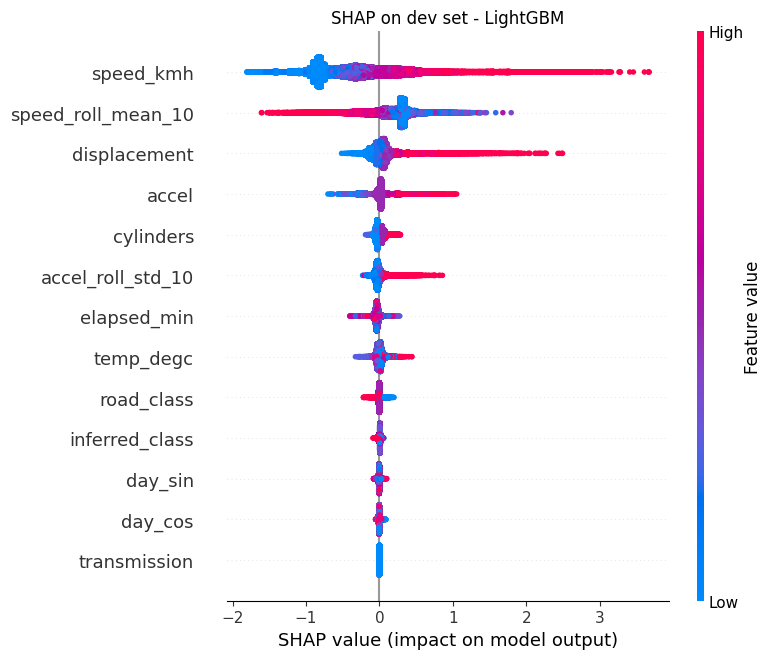

In [40]:
#sample_idx = np.random.choice(len(X_test), size=10000, replace=False)
#X_shap = X_dev.iloc[sample_idx]
#explainer = shap.TreeExplainer(model_lgbm)
#shap_values = explainer.shap_values(X_shap)
# Beeswarm (direction and magnitude of each feature)
shap.summary_plot(lgbm_shap_values, X_shap,
                  feature_names=RF_FEATURE_COLS, show=False)
plt.title(f"SHAP on dev set - LightGBM")
plt.tight_layout()
plt.show()

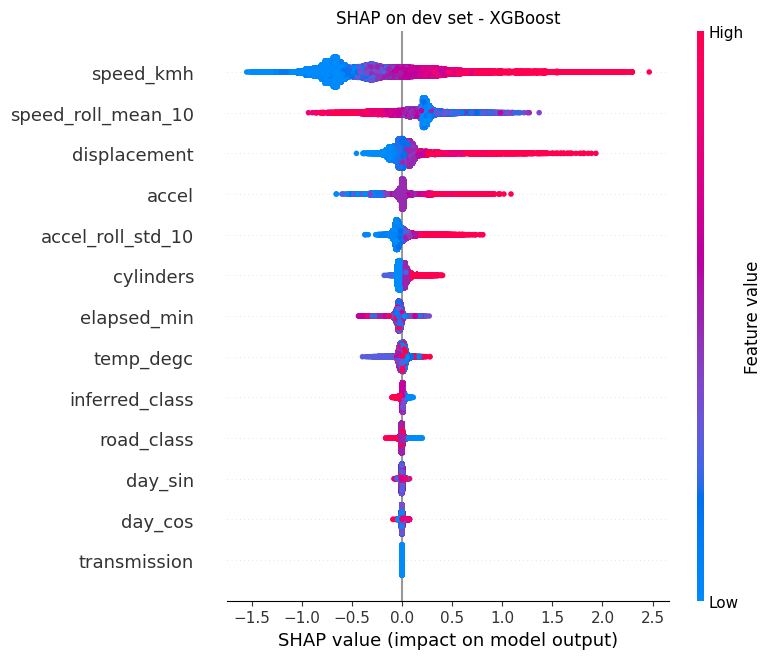

In [41]:
xgb_explainer = shap.TreeExplainer(best_xgb)
xgb_shap_values = xgb_explainer.shap_values(X_shap)
shap.summary_plot(xgb_shap_values, X_shap,
                  feature_names=RF_FEATURE_COLS, show=False)
plt.title(f"SHAP on dev set - XGBoost")
plt.tight_layout()
plt.show()

# LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
FEATURE_COLS = [
    "speed_kmh",
    "temp_degc",
    "displacement",
    "elapsed_min",
    "cylinders",
    "accel",
    "speed_roll_mean_10",
    "accel_roll_std_10"]

TARGET = "encon"

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[FEATURE_COLS])

X_dev_scaled = scaler.transform(dev[FEATURE_COLS])

X_test_scaled = scaler.transform(test[FEATURE_COLS])

In [ ]:
def create_sequences(X, y, seq_len=20):

    X_seq = []
    y_seq = []

    for i in range(seq_len, len(X)):

        X_seq.append(X[i-seq_len:i] )

        y_seq.append(y[i])

    return np.array(X_seq),np.array(y_seq)

In [ ]:
SEQ_LEN = 20

y_train = train[TARGET].values
y_dev   = dev[TARGET].values
y_test  = test[TARGET].values

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    SEQ_LEN)

X_dev_seq, y_dev_seq = create_sequences(
    X_dev_scaled,
    y_dev,
    SEQ_LEN)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    SEQ_LEN)

print(X_train_seq.shape)

(9994454, 20, 8)


In [ ]:
model = Sequential([
    LSTM(
        64,input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]),
        return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

history = model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_dev_seq,
        y_dev_seq),

    epochs=20,
    batch_size=512,

    callbacks=[early_stop],

    verbose=1)

Epoch 1/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 203s 10ms/step - loss: 0.6925 - mae: 0.6290 - val_loss: 0.5816 - val_mae: 0.5769
Epoch 2/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 259s 13ms/step - loss: 0.6910 - mae: 0.6287 - val_loss: 0.5816 - val_mae: 0.5837
Epoch 3/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 314s 16ms/step - loss: 0.6909 - mae: 0.6286 - val_loss: 0.5812 - val_mae: 0.5793
Epoch 4/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 241s 12ms/step - loss: 0.6908 - mae: 0.6286 - val_loss: 0.5817 - val_mae: 0.5861
Epoch 5/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 237s 12ms/step - loss: 0.6907 - mae: 0.6285 - val_loss: 0.5814 - val_mae: 0.5781
Epoch 6/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 243s 12ms/step - loss: 0.6907 - mae: 0.6285 - val_loss: 0.5820 - val_mae: 0.5881
Epoch 7/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 504s 26ms/step - loss: 0.6906 - mae: 0.6285 - val_loss: 0.5817 - val_mae: 0.5850
Epoch 8/20
19521/19521 ━━━━━━━━━━━━━━━━━━━━ 226s 12ms/step - loss: 0.6906 - mae: 0.6285 - val_loss: 0.5814 - val_mae: 0.5767


In [ ]:
dev_pred = model.predict(X_dev_seq).flatten()

39041/39041 ━━━━━━━━━━━━━━━━━━━━ 27s 687us/step


In [ ]:
#preds = model.predict(X_dev)
result = evaluate("LSTM", y_dev_seq, dev_pred)

LSTM on [dev]
MAE: 0.5793 L/hr
RMSE: 0.7624 L/hr
R-squared: 0.0002


In [ ]:
train_pred = model.predict(X_train_seq).flatten()
result = evaluate("LSTM", y_train_seq, train_pred)

312327/312327 ━━━━━━━━━━━━━━━━━━━━ 215s 688us/step
LSTM on [dev]
MAE: 0.6263 L/hr
RMSE: 0.8311 L/hr
R-squared: 0.0079
